# IMDB Review Sentiment Classifier

Dataset: IMDB Dataset of 50K Movie Reviews (Kaggle).

Goal: given the raw text of a review, predict whether it is `positive` or `negative`.
This is a binary text classification problem, solved here with a TF-IDF representation
feeding a Logistic Regression classifier.

Instead of exporting the trained pipeline as a pickle/joblib blob, this notebook exports
the model as a plain **JSON file** (vocabulary + IDF weights + logistic weights). That
keeps the artifact human-readable and framework-independent, and it's the format used
across the other projects in this collection.

In [15]:
import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

sns.set_style("whitegrid")

## 1. Load the dataset

In [16]:
DATA_PATH = "IMDB_Dataset.csv"

data = pd.read_csv(DATA_PATH)
print("Shape:", data.shape)
data.head()

Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


The file has two columns: `review` (raw text) and `sentiment` (`positive` / `negative`).

## 2. Quick look at the data

In [18]:
data["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


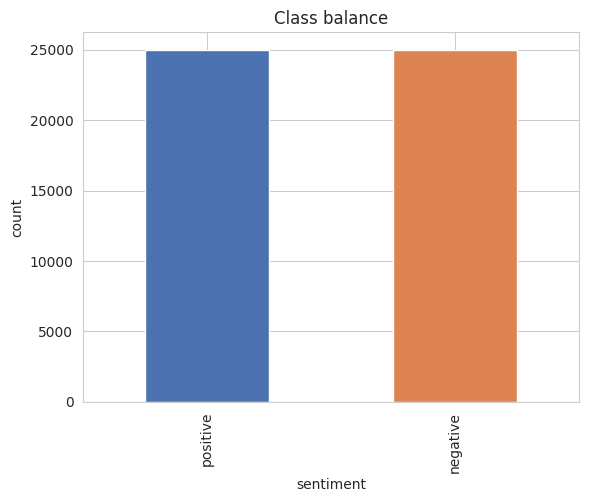

In [19]:
ax = data["sentiment"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
ax.set_title("Class balance")
ax.set_xlabel("sentiment")
ax.set_ylabel("count")
plt.show()

Classes are balanced (25k / 25k), so accuracy is a reasonable metric to track alongside precision/recall.

In [20]:
print("Missing values:\n", data.isnull().sum())
print("\nFully duplicated rows:", data.duplicated().sum())
print("Duplicated review text only:", data["review"].duplicated().sum())

Missing values:
 review       0
sentiment    0
dtype: int64

Fully duplicated rows: 418
Duplicated review text only: 418


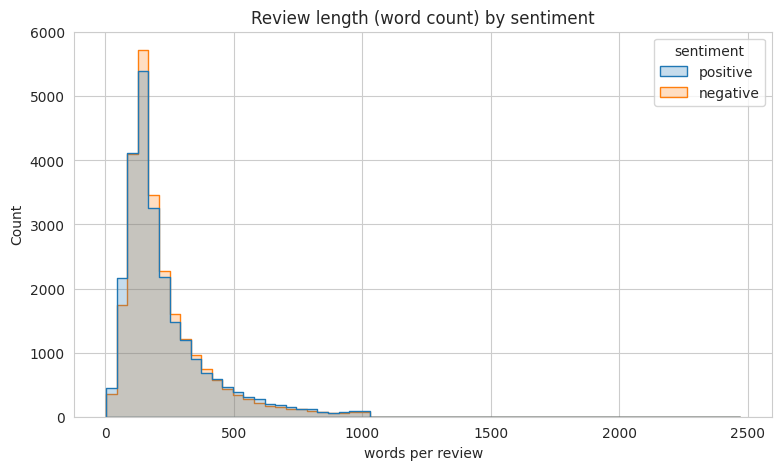

In [21]:
data["review_len"] = data["review"].str.split().apply(len)

plt.figure(figsize=(9, 5))
sns.histplot(data=data, x="review_len", hue="sentiment", bins=60, element="step")
plt.title("Review length (word count) by sentiment")
plt.xlabel("words per review")
plt.show()

Both classes follow the same right-skewed length distribution, so review length by itself won't separate the classes — the actual wording has to do the work.

## 3. Text cleaning

A single regex-based cleaning function: strip HTML tags (the raw text has a lot of `<br />`
from the original scrape), drop URLs, keep only letters, collapse whitespace, lowercase.

In [22]:
TAG_RE = re.compile(r"<[^>]+>")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
NON_ALPHA_RE = re.compile(r"[^a-zA-Z\s]")
MULTI_SPACE_RE = re.compile(r"\s+")

def clean_review(text: str) -> str:
    text = TAG_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = NON_ALPHA_RE.sub(" ", text)
    text = text.lower()
    text = MULTI_SPACE_RE.sub(" ", text).strip()
    return text

data["clean_review"] = data["review"].apply(clean_review)
data[["review", "clean_review"]].head(3)

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...


In [23]:
before = len(data)
data = data.drop_duplicates(subset="clean_review").reset_index(drop=True)
print(f"Dropped {before - len(data)} duplicate reviews after cleaning, {len(data)} remain.")

Dropped 424 duplicate reviews after cleaning, 49576 remain.


In [24]:
data["label"] = (data["sentiment"] == "positive").astype(int)
data["label"].value_counts()

,count
label,
1,24881
0,24695


## 4. Train / test split

In [25]:
X = data["clean_review"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=7
)

X_train.shape, X_test.shape

((39660,), (9916,))

In [26]:
from sklearn.pipeline import Pipeline

## 5. TF-IDF + Logistic Regression

Unigrams and bigrams, capped at 50k features, ignoring terms that appear in fewer than 3
documents or in more than 90% of them. Wrapped in a `Pipeline` so the vectorizer and the
classifier travel together as one object.

In [27]:
model_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.90,
    )),
    ("clf", LogisticRegression(max_iter=1000, C=1.0, random_state=7)),
])

model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.9, max_features=50000, min_df=3,
                                 ngram_range=(1, 2))),
                ('clf', LogisticRegression(max_iter=1000, random_state=7))])

## 6. Evaluation

In [28]:
y_pred = model_pipeline.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}\n")
print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))

Accuracy: 0.9045

              precision    recall  f1-score   support

    negative       0.91      0.90      0.90      4939
    positive       0.90      0.91      0.91      4977

    accuracy                           0.90      9916
   macro avg       0.90      0.90      0.90      9916
weighted avg       0.90      0.90      0.90      9916



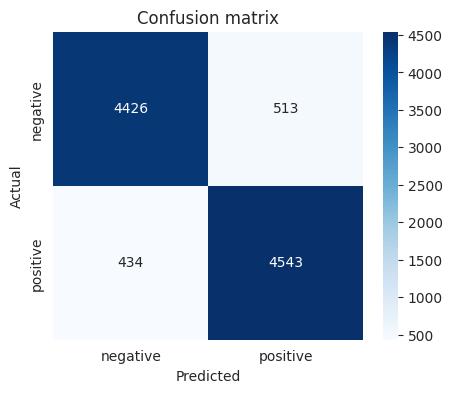

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["negative", "positive"],
            yticklabels=["negative", "positive"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

## 7. Save the model with joblib

The whole pipeline (vectorizer + classifier) is saved as a single object with `joblib`,
so the app only ever has to load one file and call `.predict()` — no separate vectorizer
step to reload by hand.

In [30]:
import os
import joblib

os.makedirs("models", exist_ok=True)
joblib.dump(model_pipeline, "models/model.joblib")

print("Saved models/model.joblib —",
      round(os.path.getsize("models/model.joblib") / 1e6, 2), "MB")

Saved models/model.joblib — 2.35 MB


## 8. Reload and sanity-check

In [31]:
loaded_pipeline = joblib.load("models/model.joblib")

def predict_sentiment(text: str) -> str:
    cleaned = clean_review(text)
    pred = loaded_pipeline.predict([cleaned])[0]
    return "positive" if pred == 1 else "negative"

print(predict_sentiment("This movie was absolutely fantastic, brilliant acting."))
print(predict_sentiment("Total waste of time, the plot made no sense at all."))

positive
negative


In [32]:
sample = X_test.sample(200, random_state=7)
sample_true = y_test.loc[sample.index]

sample_pred = loaded_pipeline.predict(sample)
agree = (sample_pred == sample_true.values).sum()

print(f"Reloaded model matches held-out labels on sample: {agree}/{len(sample)}")

Reloaded model matches held-out labels on sample: 183/200
